In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
from langchain_groq import ChatGroq

In [2]:
load_dotenv()

True

In [3]:
class substate(TypedDict):
    input_text : str
    translated_text : str

In [4]:
substate_llm=ChatGroq(
    model_name="openai/gpt-oss-120b",
    temperature=0.5,
)

In [5]:
def translate_text(state:substate):
    prompt=f"you are given a text , translate it to hindi, keep it natural and clear , do not add extra content. Text:{state['input_text']}".strip()
    translated_text=substate_llm.invoke(prompt).content

    return {'translated_text':translated_text}


In [6]:
subgraph_builder=StateGraph(substate)

subgraph_builder.add_node('translate_text',translate_text)
subgraph_builder.add_edge(START,'translate_text')
subgraph_builder.add_edge('translate_text',END)

subgraph=subgraph_builder.compile()

In [7]:
class parentstate(TypedDict):
    question : str
    answer_eng : str
    answer_hin : str
    

In [8]:
parent_llm=ChatGroq(
    model_name="llama-3.3-70b-versatile",
    temperature=0.5,
)

In [9]:
def generate_answer(state:parentstate):
    prompt=f"you are a helpful assistant. clearly answer the given question. {state['question']}"
    answer=parent_llm.invoke(prompt).content

    return {'answer_eng':answer}

In [10]:
def translate_answer(state:parentstate):
    result=subgraph.invoke({'input_text':state['answer_eng']})

    return {'answer_hin':result['translated_text']}

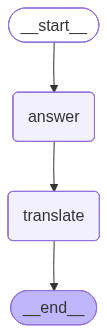

In [13]:
parent_builder=StateGraph(parentstate)

parent_builder.add_node('answer',generate_answer)
parent_builder.add_node('translate',translate_answer)

parent_builder.add_edge(START,'answer')
parent_builder.add_edge('answer','translate')
parent_builder.add_edge('translate',END)

graph=parent_builder.compile()
graph

In [14]:
graph.invoke({'question':'why is ronaldo called the greatest athlete of all time'})

{'question': 'why is ronaldo called the greatest athlete of all time',
 'answer_eng': "Cristiano Ronaldo is widely regarded as one of the greatest athletes of all time, and for good reason. Here are some key factors that contribute to his reputation:\n\n1. **Unprecedented Success**: Ronaldo has won an astonishing 27 major trophies, including five Ballon d'Or awards, four UEFA Champions League titles, and numerous league and cup titles with Manchester United, Real Madrid, and Juventus.\n2. **Consistency and Longevity**: Throughout his career, Ronaldo has consistently performed at an elite level, maintaining an incredibly high standard of play for over 15 years. He has shown remarkable durability and adaptability, playing in various positions and formations.\n3. **Record-Breaking Achievements**: Ronaldo holds numerous records in football, including:\n\t* Most UEFA Champions League goals (134)\n\t* Most UEFA Champions League hat-tricks (8)\n\t* Most international goals by a European playe